# GRN inference with Arboreto/GRNBoost2

In the previous notebook, we performed quality control on a single-cell RNA-seq dataset of mouse hematopoietic stem cells and saved the filtered raw counts to `data/filtered_counts.h5ad`.

Now we will use those counts to **infer a Gene Regulatory Network (GRN)** — a directed graph where nodes are genes and edges represent putative regulatory relationships (transcription factor → target gene).

## GRNBoost2

GRNBoost2 is an algorithm implemented in the [arboreto](https://github.com/aertslab/arboreto) package. It works in two steps:

1. **Pairwise Mutual Information (MI):** For every pair of genes, it estimates how much information they share across cells. High MI suggests co-regulation or direct regulatory relationship.
2. **Random Forest attribution:** For each gene pair, a random forest classifier tries to predict the MI value from the individual expression profiles. The feature importances tell us which gene is more likely the *regulator* (source) and which is the *target*.

The output is a list of directed edges with a **weight** (confidence score). Unlike correlation-based methods, GRNBoost2 can distinguish directionality — which gene is likely regulating the other.

## Important caveat

GRN inference from scRNA-seq data is inherently noisy. The inferred network is a *hypothesis* about regulatory relationships, not ground truth. It should be interpreted alongside known biology, validated experimentally, or cross-referenced with other data sources (ChIP-seq, ATAC-seq, perturbation experiments).

Other, more sophisticated tools (SCENIC, CellOracle) therefore extend analysis workflows like GRNBoost2 with additional data modalities (ChIP-seq, ATAC-seq) or literature-based prior knowledge, grounding the inference in known databases of regulations and transcription factors.


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from arboreto.algo import grnboost2

In [2]:
# Load the preprocessed h5ad file
adata = sc.read_h5ad("data/filtered_counts.h5ad")
print(f"Dataset shape: {adata.shape}")

Dataset shape: (14637, 17056)


In this tutorial, we will use a know list of transcription factors, i.e. genes that are known to interact with DNA and regulating expression of other genes:

In [3]:
!wget -nc https://resources.aertslab.org/cistarget/tf_lists/allTFs_mm.txt
!mv ./allTFs_mm.txt ./data

--2026-07-11 16:31:41--  https://resources.aertslab.org/cistarget/tf_lists/allTFs_mm.txt
Resolving resources.aertslab.org (resources.aertslab.org)... 134.58.50.9
Connecting to resources.aertslab.org (resources.aertslab.org)|134.58.50.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11726 (11K) [text/plain]


Saving to: ‘allTFs_mm.txt’

allTFs_mm.txt       100%[===================>]  11.45K  --.-KB/s    in 0s      

2026-07-11 16:31:42 (187 MB/s) - ‘allTFs_mm.txt’ saved [11726/11726]



An important point is that the complexity of GRNBoost2 (and most other inference methods) is quadratic in the number of genes, since in theory, any gene `A` can regulate any other gene `B`.

Here, the list of known TFs serves two purposes: First, it grounds the inference in our existing knowledge of the mechanics of gene regulation. However, it also reduces the number of all possible regulations: instead of considering all `|Genes| x |Genes|` options, we only need to consider `|TFs| x |Genes|` regulations.

While this makes the inference problem much smaller, it is still too large to run fully as part of a tutorial. Therefore, this notebook can take two "branches": Either we sub-sample our dataset to just the 300 most variable genes for which we can run the analysis in real time, or we can load a pre-computed GRN which is valid for all genes (but restricted to known transcription factors). The default configuration runs with the 300 highly variable genes, but you can switch to the pre-computed network below.

In [4]:

# 1. Normalize total counts per cell to a target sum (e.g., 10,000)
sc.pp.normalize_total(adata, target_sum=1e4)

# 2. Logarithmize the data (X = log(X + 1))
sc.pp.log1p(adata)

# 1. Select the top highly variable genes (e.g., top 300)
sc.pp.highly_variable_genes(adata, n_top_genes=300)
adata_sub = adata[:, adata.var.highly_variable].copy()

# 2. Extract the expression matrix as a Pandas DataFrame (cells x genes)
# Arboreto expects genes as columns and cells as rows
expression_df = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs_names,
    columns=adata_sub.var_names
)

# 3. Define candidate Transcription Factors (TFs)
with open("./data/allTFs_mm.txt", "r") as f:
    tf_list = [line.strip() for line in f if line.strip()]
    
# Keep only TFs that are actually present in our expression dataset
candidate_tfs = list(set(tf_list).intersection(adata_sub.var_names))

print(f"Demo shape: {expression_df.shape} (Cells x Genes)")
print(f"Number of candidate TFs: {len(candidate_tfs)}")

Demo shape: (14637, 300) (Cells x Genes)
Number of candidate TFs: 27


In [41]:
# Sidenote: We will save the HVG dataset, because we also want to use it later with pySCENIC:
import scipy.sparse as sp
import scipy.io

adata_sub.write_h5ad("data/filtered_counts_300_hvg.h5ad")

!mkdir -p data/filtered_counts_300_hvg

# ---- Save the matrix as .mtx ----
# If your matrix is dense, convert to sparse first
if not hasattr(adata_sub.X, "toarray"):
    mtx = sp.csr_matrix(adata_sub.X)
else:
    mtx = adata_sub.X

# Transpose to genes × cells (10x convention) before writing
scipy.io.mmwrite("data/filtered_counts_300_hvg/matrix.mtx", mtx.T, field="integer" if "int" in str(adata_sub.X.dtype) else "real")

# ---- Save barcodes (obs_names) ----
pd.Series(adata_sub.obs_names).to_csv("data/filtered_counts_300_hvg/barcodes.tsv", sep="\t", index=False, header=False)

# ---- Save genes/features (var_names) ----
pd.Series(adata_sub.var_names).to_csv("data/filtered_counts_300_hvg/genes.tsv", sep="\t", index=False, header=False)

Now we can actually run GRNBoost2!

 > Note that it is normal if the algorithm prints a "Stream is closed" error even if the inference finished successfully. The algorithm uses the `dask` Python package to parallelize computation for different genes across CPU cores and the parallelization process may not always shut down fully before the results are printed, which causes the error.

In [5]:
# Run GRNBoost2 on the downsized demo data
print("Inferring toy GRN... (this should take 15-30 seconds)")
toy_grn = grnboost2(
    expression_data=expression_df,
    tf_names=candidate_tfs,
    seed=0 # Make sure to fix the seed to ensure deterministic results
)

# Rename the output columns for clarity
toy_grn.columns = ['TF', 'Target', 'Importance']
print(f"Toy GRN inference complete. Found {len(toy_grn)} candidate edges.")
toy_grn.head()

Inferring toy GRN... (this should take 15-30 seconds)


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Toy GRN inference complete. Found 7565 candidate edges.


,TF,Target,Importance
14,Klf1,Tspo2,23.863905
14,Klf1,Aqp1,23.052276
14,Klf1,Gm15915,22.961904
14,Klf1,Car1,22.491840
18,Pou2af1,Cd79a,22.066223


As we can see, the output is a list of gene pairs (regulations), each with a particular importance (weight). For the remaining analysis, we can either keep using this toy network, or load the prepared network based on the complete dataset:

In [6]:
# Load the pre-computed full GRN
# (Make sure 'full_grn_results.tsv' is in your directory)
#full_grn = pd.read_csv("full_grn_results_1000.tsv", sep="\t")
#full_grn.columns = ['TF', 'Target', 'Importance']

full_grn = toy_grn
print(f"Loaded GRN with {len(full_grn)} interactions.")

Loaded GRN with 7565 interactions.


## Network analysis

Assuming we are working with the toy network, we now know that there are 300 genes in it, out of these 27 are transcription factors, and they influence the remaining genes through 7565 interactions (almost exactly the whole possible graph of `27 * 299 = 8073` edges). Thanks to the weight score, we can identify which if these interactions are actually more important, but there is generally no "universally correct" cut off threshold at which the edges must be discarded.

Most often, studies choose to introduce an artificial cutoff based on the assumption that biological networks are typically sparse. In other words, on average, a single gene should only have a few regulators. In the idealized model, this could be as low as 2 or 3. Here, because we have 300 genes, we'll set the cutoff to 1000 edges. In the figure below, we see that this covers almost 70% of the cumulative regulation weight across the whole network. However, do note that this can also eliminate some genes from our GRN, as we are not guaranteed that each gene retains at least one edge. Similarly, it does not guarantee that our GRN will be connected. We could end up with several disjoint regulatory sub-networks. This simply means that the data does not provide enough information to identify viable regulators for the eliminated genes: either the expression of these genes is not actually variable, or we don't have enough data to reliably infer a high confidence regulator (it may even be true that our initial list of TFs is incomplete!).

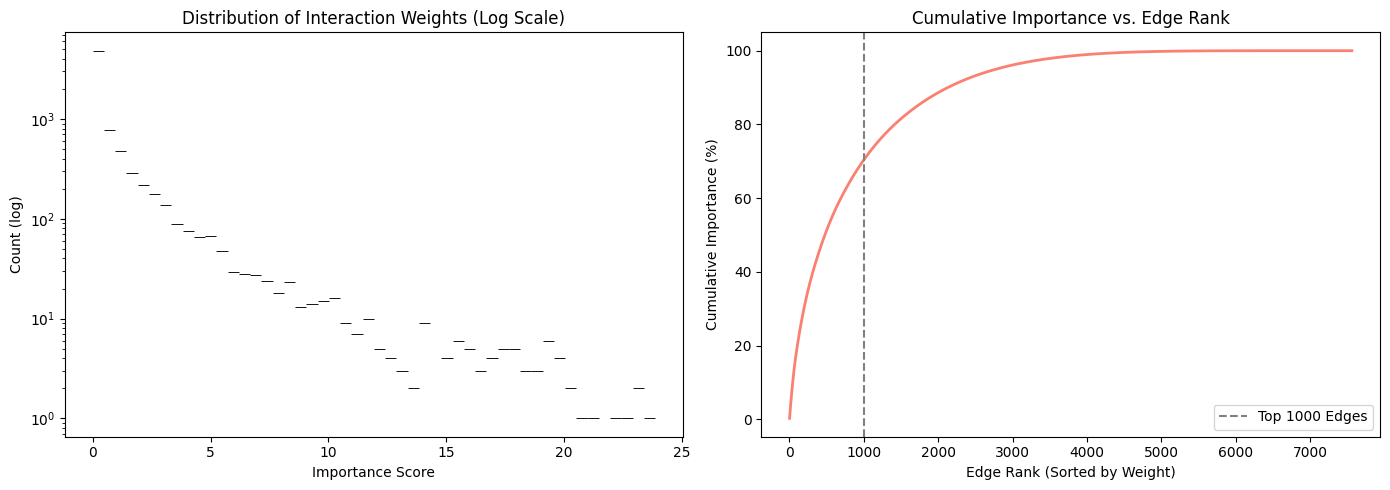

In [7]:
# Sort the edges by importance descending
full_grn = full_grn.sort_values(by="Importance", ascending=False).reset_index(drop=True)
full_grn['Rank'] = full_grn.index + 1

# Calculate cumulative importance percentage
total_importance = full_grn['Importance'].sum()
full_grn['Cumulative_Importance_Pct'] = (full_grn['Importance'].cumsum() / total_importance) * 100

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weight distribution (Log scale on Y)
sns.histplot(data=full_grn, x='Importance', bins=50, ax=axes[0], log_scale=(False, True), color='skyblue')
axes[0].set_title("Distribution of Interaction Weights (Log Scale)")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Count (log)")

# Plot 2: Cumulative weight fall-off depending on rank
axes[1].plot(full_grn['Rank'], full_grn['Cumulative_Importance_Pct'], color='salmon', lw=2)
axes[1].axvline(x=1000, color='gray', linestyle='--', label='Top 1000 Edges')
axes[1].set_title("Cumulative Importance vs. Edge Rank")
axes[1].set_xlabel("Edge Rank (Sorted by Weight)")
axes[1].set_ylabel("Cumulative Importance (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Threshold the network to the top 1,000 edges
thresholded_grn = full_grn.head(1000).copy()
print(f"Filtered network has {len(thresholded_grn)} edges.")

Filtered network has 1000 edges.


It can be also useful to visualize the edges of the network with highest confidence. Of course, we can't reasonably comprehend a network with 1000 edges, but even the first 50 or 100 can be illustrative of "the most important" genes in the network. Alternatively, we could also visualize sub-networks involving specific genes or transcription factors.

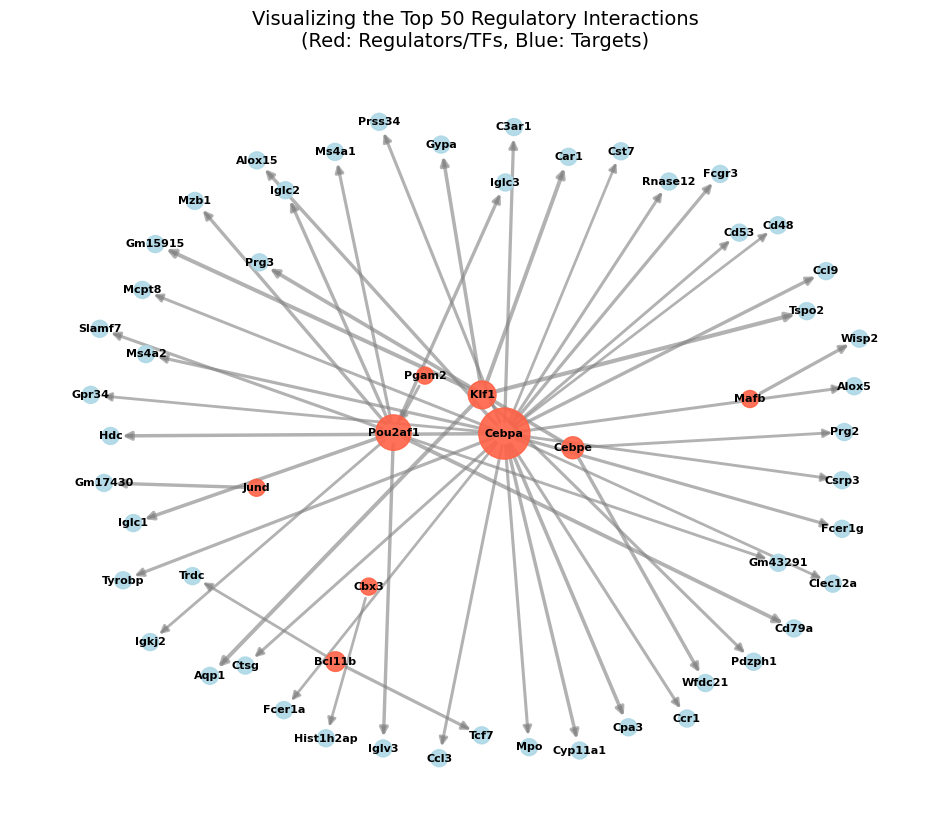

In [9]:
# Filter for the top 50 edges for visualization
viz_df = thresholded_grn.head(50)

# Create a Directed Graph in NetworkX
G = nx.from_pandas_edgelist(
    viz_df, 
    source='TF', 
    target='Target', 
    edge_attr='Importance', 
    create_using=nx.DiGraph()
)

# Identify unique TFs (source nodes) in this sub-network
source_tfs = set(viz_df['TF'])

# Assign node colors: Red for TFs, Blue for Targets (that aren't TFs in this subset)
node_colors = []
for node in G.nodes():
    if node in source_tfs:
        node_colors.append('tomato')
    else:
        node_colors.append('lightblue')

# Scale node sizes based on their total degree (in-degree + out-degree)
node_sizes = [ (G.degree(node) * 50) + 100 for node in G.nodes() ]

# Scale edge widths based on their normalized importance
weights = [G[u][v]['Importance'] for u, v in G.edges()]
max_weight = max(weights)
edge_widths = [ (w / max_weight) * 3 for w in weights ]

# Generate layout
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.4, seed=42)

# Draw graph components
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.6, arrowsize=12)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Visualizing the Top 50 Regulatory Interactions\n(Red: Regulators/TFs, Blue: Targets)", fontsize=14)
plt.axis('off')
plt.show()

While this is certainly useful, it is also not very rigorous. It is very well possible that the nodes important for the 50 top-most regulations are completely irrelevant for the rest. As such, we often want to compute more general statistics about the network structure.

Note that here, we are only considering the 1000 most significant regulations. However, most of these methods can be also extended to take into account the weight of individual edges. In that case, we could consider the whole network, with the expectation that low-importance edges will be contribute less to the respective metrics.

In [10]:
# Build a NetworkX graph from our full thresholded network (1000 edges)
G_full = nx.from_pandas_edgelist(
    thresholded_grn, 
    source='TF', 
    target='Target', 
    edge_attr='Importance', 
    create_using=nx.DiGraph()
)

The most trivial option is to consider which TFs regulate the most downstream genes. Note that in realistic biological networks, we often see this pattern of "master TFs" that regulate a very large portion of the genome, and the more targeted TFs that regulate small groups of function-specific genes. However, in general, we expect to see a relatively small group of nodes (TFs) regulating a large group of downstream genes. Still, a TF can of course also regulate the expression of other TFs. As a result, a realistic GRN often consists of a small "connected component" of TFs regulating each other, and a much large group of downstream function-specific genes regulated by a small subset of the "TF connected component".

In [11]:
# Calculate degrees
out_degrees = dict(G_full.out_degree())
in_degrees = dict(G_full.in_degree())

# Convert to DataFrame
degree_df = pd.DataFrame({
    'Out_Degree': pd.Series(out_degrees),
    'In_Degree': pd.Series(in_degrees)
}).fillna(0)

# Display top 10 Master Regulators (high out-degree)
print("Top 10 Candidate Master Regulators (by Out-Degree):")
print(degree_df.sort_values(by='Out_Degree', ascending=False).head(10))

Top 10 Candidate Master Regulators (by Out-Degree):
        Out_Degree  In_Degree
Jund           107         10
Junb           106          5
Klf2            84          5
Cebpa           84          4
Id2             61          4
Id1             59          5
Fos             56          8
Cbx3            56          4
Hes1            48          4
Bcl11b          41          3


We can also consider a somewhat more sophisticated metrics of TF importance. In pagerank, each node is assigned equal initial importance, but then re-distributes this importance equally into all the nodes that it links to. This repeats until the scores converge. Consequently, TFs that are regulated by most other TFs without re-distributing this influence too much achieve the highest ranks:

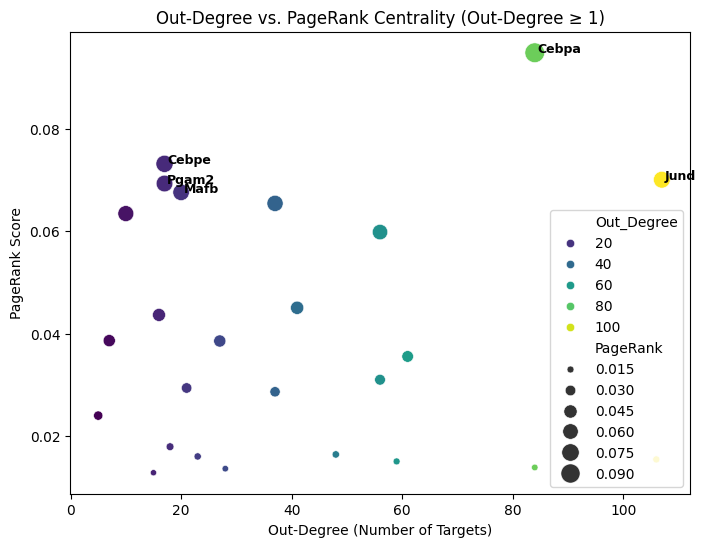

In [12]:
# --- Filter to only nodes with out-degree >= 1 ---
# Keep only nodes that have at least one outgoing edge
nodes_with_outdeg = [n for n, d in G_full.out_degree() if d >= 1]
G_filtered = G_full.subgraph(nodes_with_outdeg).copy()

# Calculate weighted PageRank on the filtered graph (using 'Importance' as the transition weight)
pagerank_scores = nx.pagerank(G_filtered, weight='Importance')

# Add to our stats DataFrame
# Only assign PageRank to nodes that are in the filtered graph; others get NaN
degree_df['PageRank'] = pd.Series(pagerank_scores)

# Scatter plot of Out-Degree vs. PageRank (drop rows without a PageRank, i.e. excluded sinks)
plot_df = degree_df.dropna(subset=['PageRank'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='Out_Degree',
    y='PageRank',
    hue='Out_Degree',
    palette='viridis',
    size='PageRank',
    sizes=(20, 200),
)

# Label the top 5 TFs by PageRank
top_tfs = plot_df.sort_values(by='PageRank', ascending=False).head(5)
for gene, row in top_tfs.iterrows():
    plt.text(row['Out_Degree'] + 0.5, row['PageRank'], gene, fontsize=9, weight='bold')

plt.title("Out-Degree vs. PageRank Centrality (Out-Degree ≥ 1)")
plt.xlabel("Out-Degree (Number of Targets)")
plt.ylabel("PageRank Score")
plt.show()

Finally, betweenness centrality captures a similar idea: It computes the shortest path between all pairs of nodes, and then for each gene computes how many shortest paths it appears on. This often tends to prioritize nodes with more connections overall, especially if these connections then lead to other parts of the graph that are only connected by that node.

In [13]:
# Create an inverted 'distance' weight attribute
for u, v, d in G_full.edges(data=True):
    # Avoid division by zero by adding a tiny epsilon
    d['distance'] = 1.0 / (d['Importance'] + 1e-5)

# Calculate betweenness centrality using the inverted distance metric
betweenness = nx.betweenness_centrality(G_full, weight='distance')
degree_df['Betweenness'] = pd.Series(betweenness)

print("\nTop 5 Genes by Betweenness Centrality (Bridges):")
print(degree_df.sort_values(by='Betweenness', ascending=False)['Betweenness'].head(5))


Top 5 Genes by Betweenness Centrality (Bridges):
Jund     0.026486
Cebpa    0.017890
Cbx3     0.016621
Id2      0.013333
Irf8     0.011156
Name: Betweenness, dtype: float64


## Appendix: Enrichment analysis

Once we have selected key genes of our GRN, we can try to validate whether the process we are describing agrees with the generally known effects of these genes. For this purpose, scientists maintain large databases that group genes and broad "ontology terms" (e.g. "T-cell differentiation") based on known literature. 

Using such database, we can identify if out group of "important genes" associates with some term more than would be expected if we just picked the genes randomly.

In [14]:
import gseapy as gp

In [15]:
# Extract top 30 regulators (i.e., all for the toy network)
#top_regulators = degree_df.sort_values(by='Out_Degree', ascending=False).head(100).index.tolist()
top_regulators = degree_df.sort_values(by='Betweenness', ascending=False)['Betweenness'].head(30).index.tolist()

print(f"Top {len(top_regulators)} Regulators to test: \n{top_regulators}")

Top 30 Regulators to test: 
['Jund', 'Cebpa', 'Cbx3', 'Id2', 'Irf8', 'Bcl11b', 'Pgam2', 'Junb', 'Pou2af1', 'Atf3', 'Klf2', 'Klf1', 'Id1', 'Mafb', 'Cebpe', 'Fos', 'Hes1', 'Klrg1', 'Wisp2', 'Tcf7', 'Klf4', 'Nr4a2', 'Egr1', 'Fosb', 'Nr4a1', 'Ifit1', 'Igkv19-93', 'Csf2', 'Xcl1', 'Cdkn1a']


In [16]:
try:
    # Run the online enrichment analysis
    enr = gp.enrichr(
        gene_list=top_regulators,
        gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
        organism='mouse',  
        outdir=None        # Keep results in memory instead of writing files to disk
    )
    
    # Store results in a pandas DataFrame
    enrichment_df = enr.results
    print("Enrichment run complete!")
    
except Exception as e:
    print(f"Error querying Enrichr API: {e}")
    print("Please check your internet connection and try again.")

Enrichment run complete!


In [17]:
# Filter for significant results
sig_enrichment = enrichment_df[enrichment_df['Adjusted P-value'] < 0.05].copy()

# Sort by significance
sig_enrichment = sig_enrichment.sort_values(by='Adjusted P-value')

print(f"Found {len(sig_enrichment)} significantly enriched pathways.")
# Display the top 10 most significant results
sig_enrichment[['Gene_set', 'Term', 'Adjusted P-value', 'Overlap', 'Genes']].head(10)

Found 149 significantly enriched pathways.


,Gene_set,Term,Adjusted P-value,Overlap,Genes
0,GO_Biological_Process_2023,Regulation Of DNA-templated Transcription (GO:...,1.845463e-15,23/1922,CEBPA;EGR1;CSF2;JUND;CEBPE;CBX3;TCF7;FOS;KLF4;...
1,GO_Biological_Process_2023,Regulation Of Transcription By RNA Polymerase ...,3.071165e-15,23/2028,CEBPA;EGR1;JUND;BCL11B;CEBPE;CBX3;TCF7;FOS;KLF...
2,GO_Biological_Process_2023,Positive Regulation Of DNA-templated Transcrip...,1.193502e-12,18/1243,CEBPA;EGR1;JUND;BCL11B;CEBPE;FOS;KLF4;KLF2;KLF...
3,GO_Biological_Process_2023,Positive Regulation Of Transcription By RNA Po...,1.043759e-10,15/938,CEBPA;EGR1;JUND;BCL11B;CEBPE;FOS;KLF4;KLF2;NR4...
4,GO_Biological_Process_2023,Negative Regulation Of DNA-templated Transcrip...,2.991627e-10,15/1025,CEBPA;CSF2;JUND;CBX3;KLF4;KLF2;NR4A2;MAFB;ID2;...
5,GO_Biological_Process_2023,Negative Regulation Of Transcription By RNA Po...,1.787333e-09,13/763,CEBPA;JUND;CBX3;KLF4;KLF2;NR4A2;MAFB;ID2;ID1;I...
6,GO_Biological_Process_2023,Integrated Stress Response Signaling (GO:0140467),4.404575e-08,5/29,CEBPA;MAFB;CEBPE;FOS;JUNB
498,KEGG_2021_Human,"Parathyroid hormone synthesis, secretion and a...",1.090271e-06,6/106,NR4A2;EGR1;CDKN1A;JUND;MAFB;FOS
7,GO_Biological_Process_2023,Fat Cell Differentiation (GO:0045444),2.029154e-06,5/62,NR4A2;CEBPA;NR4A1;MAFB;KLF4
8,GO_Biological_Process_2023,Negative Regulation Of Nucleic Acid-Templated ...,1.431476e-05,8/456,CEBPA;CSF2;CBX3;ID2;ID1;XCL1;HES1;KLF4


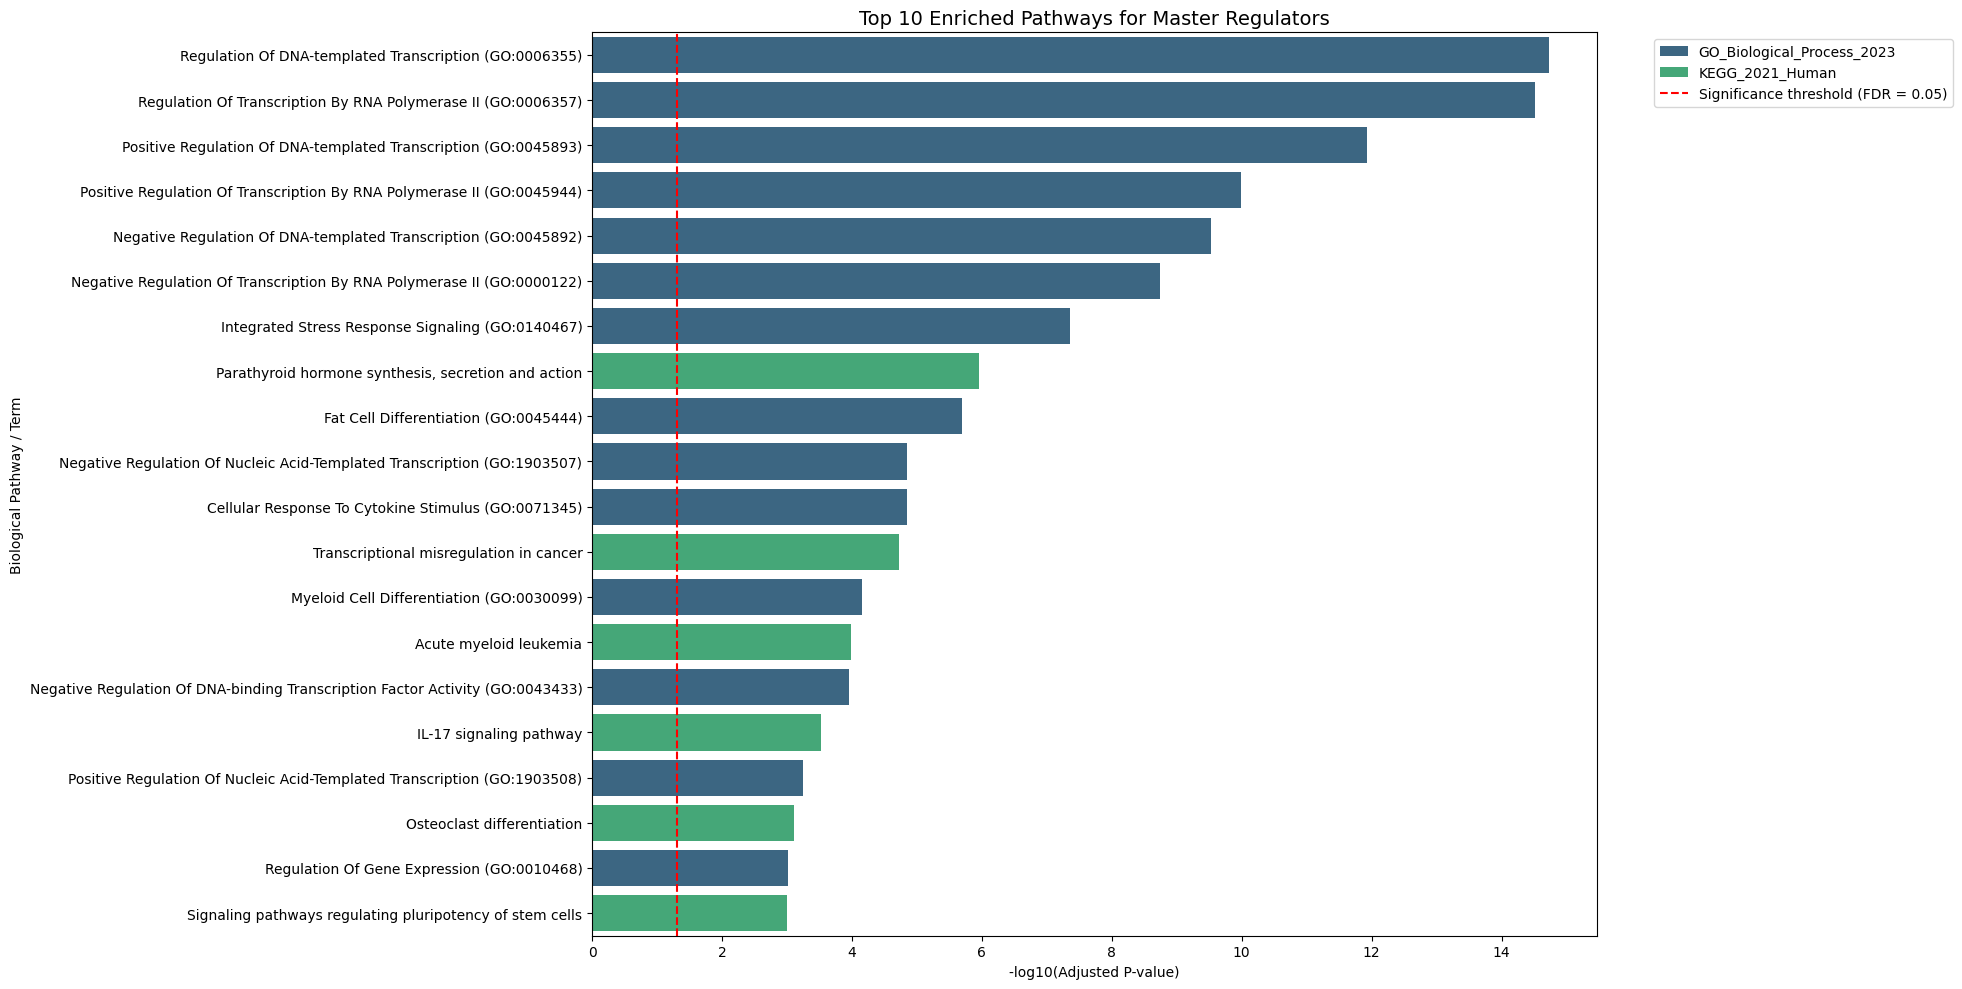

In [18]:
if not sig_enrichment.empty:
    # Select top 10 rows
    plot_data = sig_enrichment.head(20).copy()
    
    # Calculate -log10 Adjusted P-value
    plot_data['-log10_Adj_P'] = -np.log10(plot_data['Adjusted P-value'])
    
    # Draw plot
    plt.figure(figsize=(20, 10))
    sns.barplot(
        data=plot_data,
        x='-log10_Adj_P',
        y='Term',
        hue='Gene_set',
        dodge=False,
        palette='viridis'
    )
    
    plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='Significance threshold (FDR = 0.05)')
    plt.title("Top 10 Enriched Pathways for Master Regulators", fontsize=14)
    plt.xlabel("-log10(Adjusted P-value)")
    plt.ylabel("Biological Pathway / Term")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No terms were significantly enriched below FDR 0.05.")
    print("Try increasing your candidate master regulator list (e.g., top 50 or 100 TFs).")

We do see that at the top of our list, there are several categories associated with generic gene regulation (DNA transcription) and general differentiation processes for different cells types. In general, this is not unexpected, because genes can often play role in several unrelated differentiation trajectories. 

We also see that many of these terms are connected to white cells (IL-17 signalling), or hematopoiesis in general (e.g., myeloid differentiation, pluripotency signalling, ...). 

However, keep in mind that this result is slightly biased: We already selected genes that are highly variable in our data. In other words, assuming our dataset is reasonable, our initial filtering step already predisposes us to only consider genes that have some non-trivial connection to hematopoiesis. In such case, enrichment analysis can be a useful validation step, but alone is not enough to prove that the GRN has "discovered" something new that the filtering step hasn't.